# K-Nearest Neighborhood (KNN) Analysis
- In vivo data is more complicated and larger in scale, so a way to analyze it is by looking at the neighborhood composition of each cell.
- We can then use the neighborhoood composition to see how similar the cells are to each other.
- This analysis is done similar to Weng et al. 2023 (Fig.2g) https://www.nature.com/articles/s41586-024-07066-z
- Github notebook: https://github.com/sankaranlab/redeem_reproducibility/blob/master/Note-4%20Human%20Hematopoiesis%20ReDeeM.ipynb

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

# Read distance matrix

In [19]:
# read the stats text file which contains the distance matrix output from the phylo module
# alternatively, use can extract the info from the *distDick.pkl dictionary ouput
stats_text = open("/home/tcheng/Projects/RETrace/2025_RETrace2_MSH2_Female_Combined/results_10000targets_3000cpgs/phylo/2025_MSH2_female_combined.buildPhylo.stats.txt").read()

# Extract the distance matrix
lines = stats_text.strip().split('\n')
start_idx = lines.index("Distance Matrix (pairwise distances between samples):") + 1
end_idx = lines.index("Target Matrix (number of shared targets between samples):") -1
matrix_lines = lines[start_idx:end_idx]

# Parse the header (sample names)
header = matrix_lines[0].split(',')[1:]  
samples = [line.split(',')[0] for line in matrix_lines[1:]]  # Sample names from rows

# check if the header and samples are the same
print(header == samples)

# Parse the distance values
distance_data = []
for line in matrix_lines[1:]:
    values = line.split(',')[1:]  # Skip the sample name
    distance_data.append([float(v) for v in values])

# Convert to pandas DataFrame
distance_df = pd.DataFrame(distance_data, index=samples, columns=header)
distance_df.head()

# Convert to NumPy matrix
pairwise_distance_matrix = distance_df.to_numpy()

True


<Axes: >

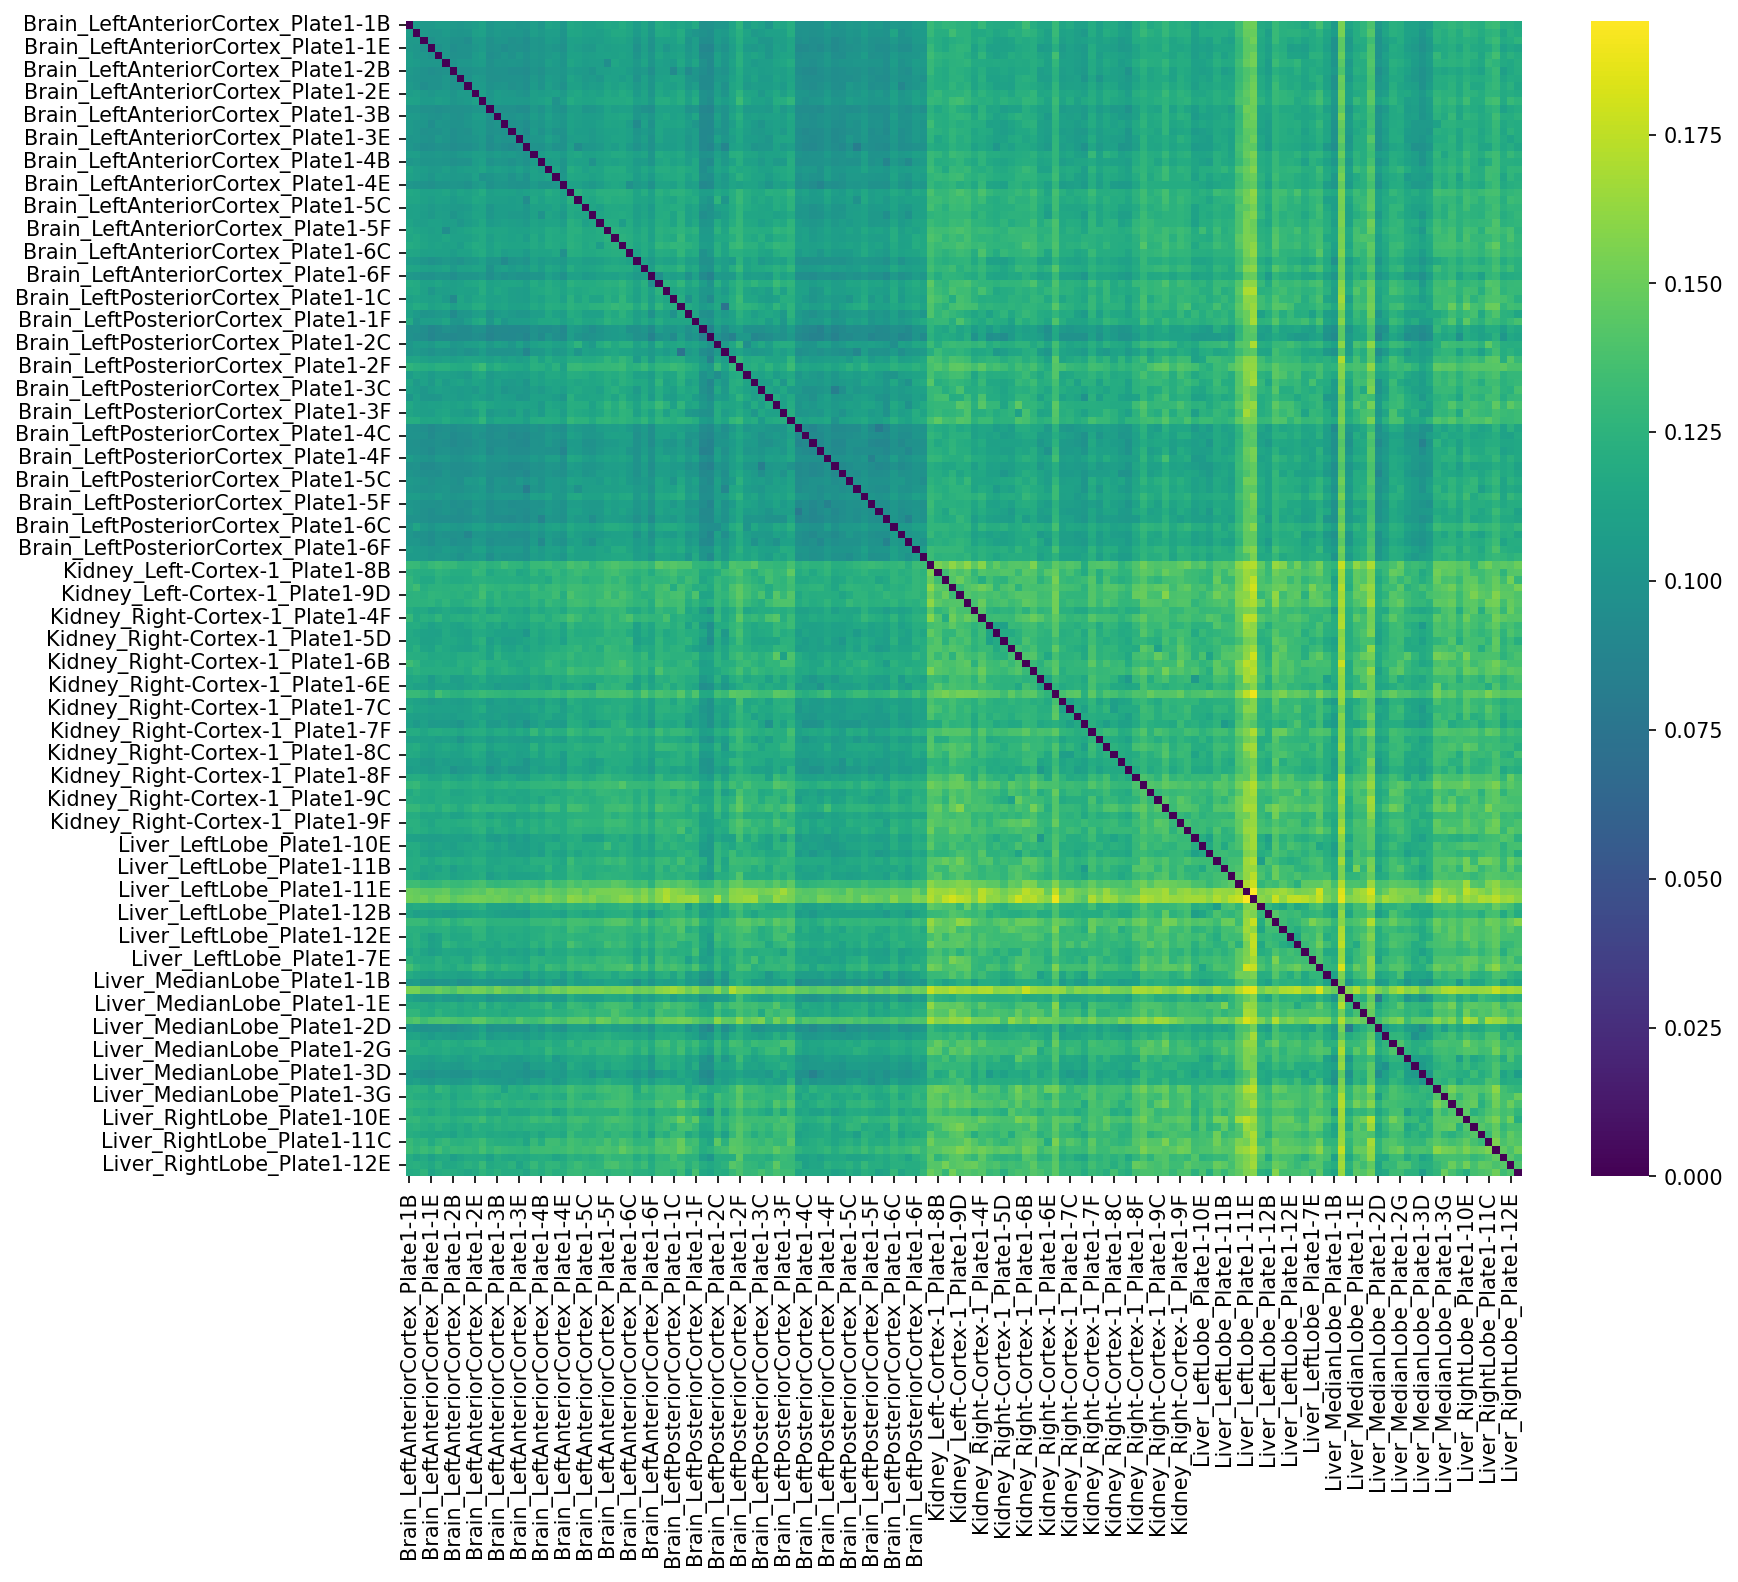

In [20]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=150)
sns.heatmap(distance_df, cmap='viridis')

# Adjust raw distance with total divergence
- This could be optional and depends on the biology quesition. Do you want to find the neighbor with the closest genetic distance (number of mutations) or the nearest neighbor in terms of developmental path?
- If latter, I find it make more sense to adjust the distance with total divergence to better identify the true evolutionary neighbor.
- This is the same as calculating the Q matrix before doing neighbor joining for phylogenetic tree construction.
- The reason is different cell type lineages have different evolutionary rates (some divide faster and have higher mutation rate), so the distance matrix needs to be adjusted accordingly.

In [21]:
def compute_q_matrix(distance_matrix):
    n = distance_matrix.shape[0]  # Number of cells
    net_divergence = np.sum(distance_matrix, axis=1)  # Net divergence for each cell

    # Initialize the Q-matrix
    q_matrix = np.zeros((n, n))

    # Calculate Q matrix values
    for i in range(n):
        for j in range(n):
            if i != j:
                q_matrix[i, j] = distance_matrix[i, j] - net_divergence[i]/(n-2) - net_divergence[j]/(n-2)
    
    return q_matrix

# Compute the divergence-adjusted distance matrix (Q matrix)
divergence_adjusted_distance_matrix = compute_q_matrix(pairwise_distance_matrix)

In [22]:
# Use divergence-adjusted distance matrix for further analysis (Optional)
pairwise_distance_matrix = divergence_adjusted_distance_matrix

# KNN Analysis
- Set number of neighbors (k) that ideally captures the bilogically relevant neighborhood. 
- This depends on your biological question and the size of your dataset.
- For this example, we have ~150 cells in the phylogenetic tree, and visually we can see major clades consisting of 10-20 cells, which capture the tissue development pattern for early progenitor.
- I tested k=10-20, all reproduce the consistent pattern that tissues from same organ are grouped together.
- I set k=15 for this example, which is consistent with the clade size observed in the tissue composition by clade analysis.

In [23]:
# set k value as the number of nearest neighbor cells to consider
k_neighbors = 15

# get the tissue types in our samples
tissue_type_labels = [f"{sample.split('_')[0]}_{sample.split('_')[1]}" for sample in samples]

# get the unique tissue types
unique_tissue_types = np.unique(tissue_type_labels)
num_tissue_types = len(unique_tissue_types)

# we need to encode the tissue types as integers because numbers are faster to compute than strings
tissue_type_to_index_mapping = {tissue_type: idx for idx, tissue_type in enumerate(unique_tissue_types)}

# encode the tissue types as integers
encoded_tissue_types = np.array([tissue_type_to_index_mapping[tissue_type] for tissue_type in tissue_type_labels])

In [24]:
# check cell counts for each tissue type
pd.Series(tissue_type_labels).value_counts()

Brain_LeftPosteriorCortex    36
Brain_LeftAnteriorCortex     35
Kidney_Right-Cortex-1        30
Liver_LeftLobe               18
Liver_MedianLobe             17
Liver_RightLobe              10
Kidney_Left-Cortex-1          6
Name: count, dtype: int64

In [25]:
# Compute cell by tissue type matrix: for each cell, counts of types in its k NN (excluding self)
cell_type_count_matrix = np.zeros((len(tissue_type_labels), num_tissue_types), dtype=float)

for i in range(len(tissue_type_labels)):
    distances_from_cell_i = pairwise_distance_matrix[i]
    nearest_neighbor_indices = np.argsort(distances_from_cell_i)
    k_nearest_neighbors = nearest_neighbor_indices[1:k_neighbors+1]  # Exclude self
    neighbor_tissue_types = encoded_tissue_types[k_nearest_neighbors]
    tissue_type_counts = np.bincount(neighbor_tissue_types, minlength=num_tissue_types)
    cell_type_count_matrix[i] = tissue_type_counts
    
# Create DataFrame with tissue type composition for each cell
knn_composition_df = pd.DataFrame(cell_type_count_matrix, columns=unique_tissue_types)
knn_composition_df['Seed'] = tissue_type_labels
knn_composition_df.head()

,Brain_LeftAnteriorCortex,Brain_LeftPosteriorCortex,Kidney_Left-Cortex-1,Kidney_Right-Cortex-1,Liver_LeftLobe,Liver_MedianLobe,Liver_RightLobe,Seed
0,0.0,3.0,1.0,4.0,1.0,4.0,2.0,Brain_LeftAnteriorCortex
1,1.0,4.0,1.0,2.0,4.0,1.0,2.0,Brain_LeftAnteriorCortex
2,1.0,4.0,2.0,2.0,3.0,2.0,1.0,Brain_LeftAnteriorCortex
3,1.0,4.0,0.0,3.0,2.0,1.0,4.0,Brain_LeftAnteriorCortex
4,3.0,4.0,0.0,3.0,3.0,1.0,1.0,Brain_LeftAnteriorCortex


In [26]:
# Aggregate by seed group - calculate mean neighbor composition for each tissue type
neighbor_composition_by_seed = knn_composition_df.groupby('Seed').mean().reset_index()
neighbor_composition_by_seed.head()

,Seed,Brain_LeftAnteriorCortex,Brain_LeftPosteriorCortex,Kidney_Left-Cortex-1,Kidney_Right-Cortex-1,Liver_LeftLobe,Liver_MedianLobe,Liver_RightLobe
0,Brain_LeftAnteriorCortex,1.771429,3.542857,0.742857,3.000000,2.342857,2.171429,1.428571
1,Brain_LeftPosteriorCortex,1.805556,4.555556,0.833333,3.277778,1.833333,1.722222,0.972222
2,Kidney_Left-Cortex-1,0.833333,3.500000,1.333333,4.000000,2.166667,1.833333,1.333333
3,Kidney_Right-Cortex-1,1.000000,3.100000,0.866667,4.533333,2.366667,1.833333,1.300000
4,Liver_LeftLobe,1.555556,2.000000,0.888889,2.777778,3.722222,2.333333,1.722222


## Normalize each column for relative enrichment
- This is to calcuate the relative enrichment instead of looking at raw counts
- This is important as some cell types are more abundant than others

In [27]:
tissue_type_columns = neighbor_composition_by_seed.columns[1:]  # Exclude 'Seed'
normalized_neighbor_composition = neighbor_composition_by_seed.copy()
for tissue_type_col in tissue_type_columns:
    column_mean = normalized_neighbor_composition[tissue_type_col].mean()
    normalized_neighbor_composition[tissue_type_col] = normalized_neighbor_composition[tissue_type_col] / column_mean if column_mean > 0 else 0

normalized_neighbor_composition.head()

,Seed,Brain_LeftAnteriorCortex,Brain_LeftPosteriorCortex,Kidney_Left-Cortex-1,Kidney_Right-Cortex-1,Liver_LeftLobe,Liver_MedianLobe,Liver_RightLobe
0,Brain_LeftAnteriorCortex,1.305911,1.188701,0.856536,0.858976,0.888352,0.989310,0.971107
1,Brain_LeftPosteriorCortex,1.331070,1.528481,0.960858,0.938511,0.695153,0.784650,0.660892
2,Kidney_Left-Cortex-1,0.614340,1.174321,1.537373,1.145301,0.821545,0.835273,0.906367
3,Kidney_Right-Cortex-1,0.737208,1.040113,0.999293,1.298008,0.897380,0.835273,0.883707
4,Liver_LeftLobe,1.146768,0.671041,1.024915,0.795348,1.411372,1.063075,1.170724


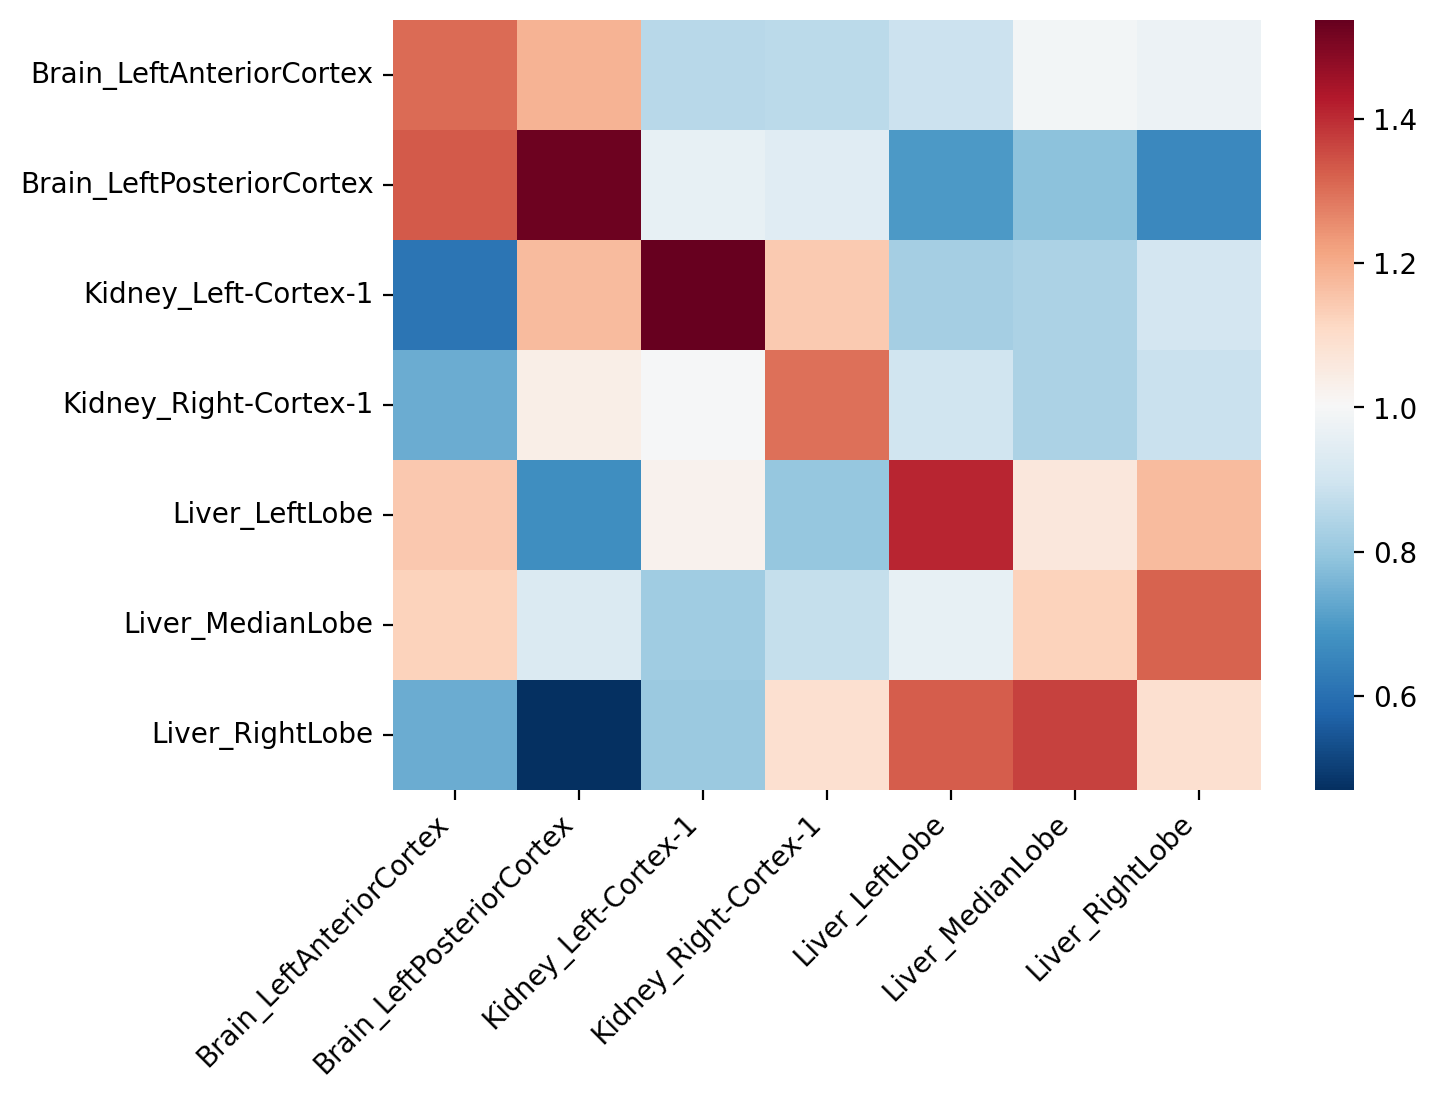

In [28]:
# Heatmap of normalized neighbor composition. 1 means no enrichment, >1 means enrichment.
fig, ax = plt.subplots(figsize=(7, 5), dpi=200)
sns.heatmap(normalized_neighbor_composition.iloc[:, 1:], cmap='RdBu_r',
           yticklabels=normalized_neighbor_composition['Seed'], ax=ax)

plt.xticks(rotation=45, ha='right') 

plt.show()

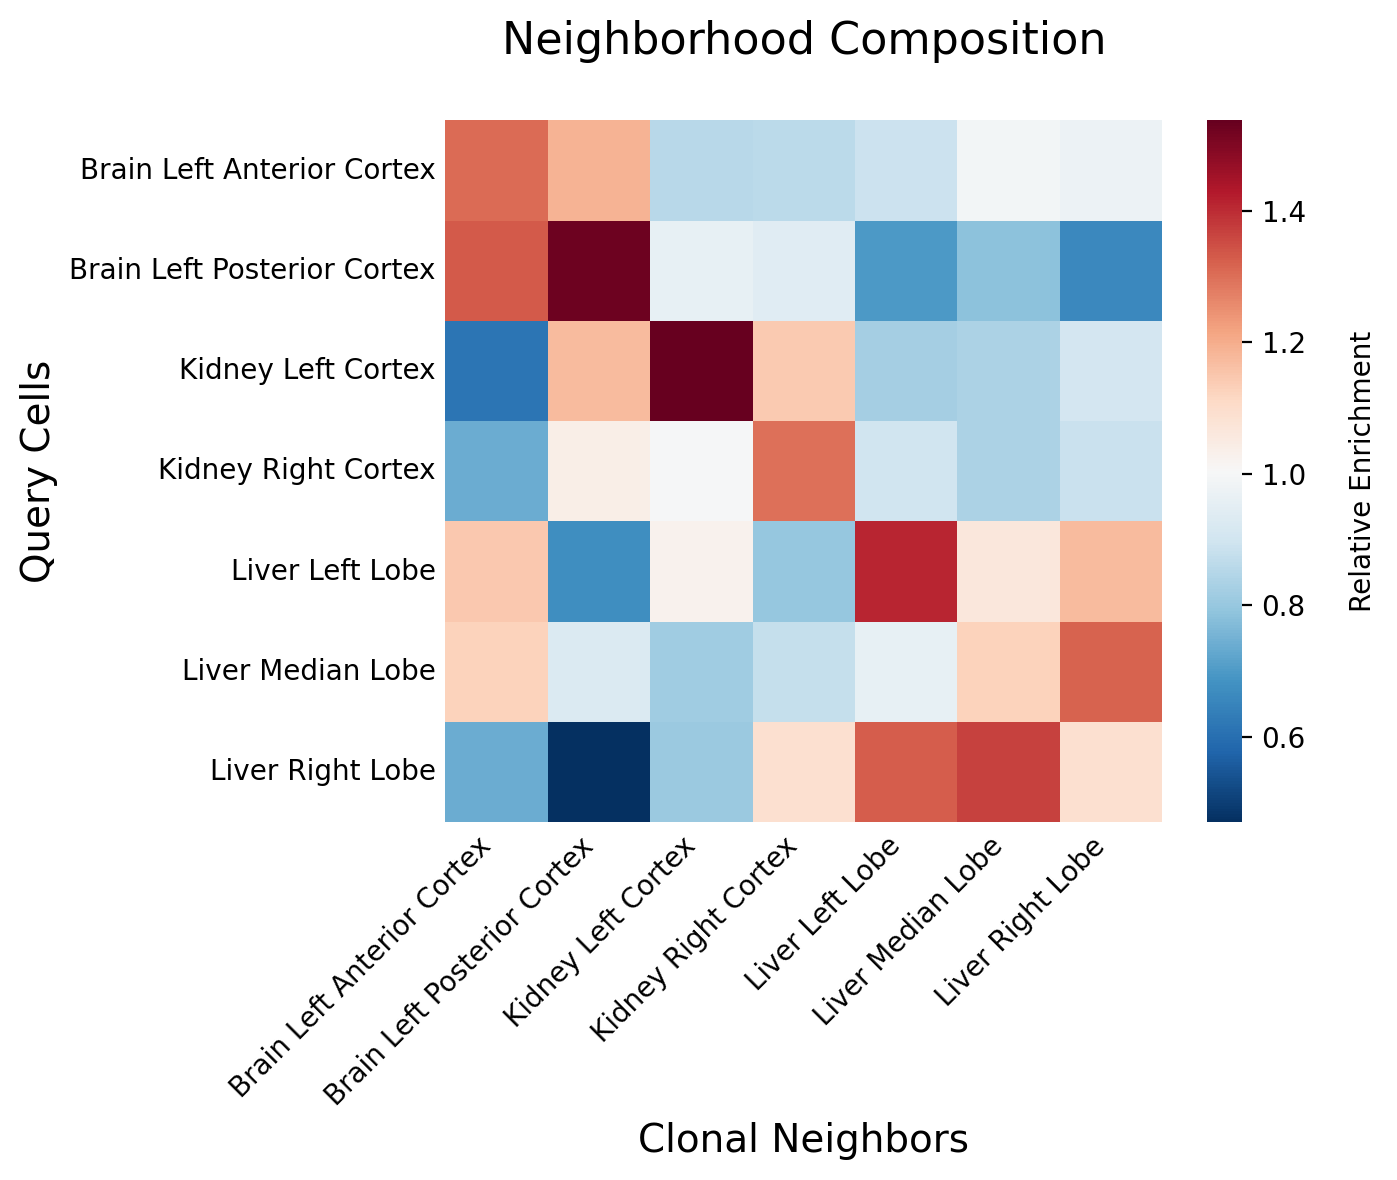

In [29]:
# For publication figure
# Rename samples for plotting
rename_dict = {'Brain_LeftAnteriorCortex': 'Brain Left Anterior Cortex',
                'Brain_LeftPosteriorCortex': 'Brain Left Posterior Cortex',
                'Kidney_Left-Cortex-1': 'Kidney Left Cortex',
                'Kidney_Right-Cortex-1': 'Kidney Right Cortex',
                'Liver_LeftLobe': 'Liver Left Lobe',
                'Liver_MedianLobe': 'Liver Median Lobe',
                'Liver_RightLobe': 'Liver Right Lobe',
                'Seed': 'Seed'}

normalized_neighbor_composition_plot = normalized_neighbor_composition.copy()
normalized_neighbor_composition_plot.index = [rename_dict[seed.lstrip('S.')] for seed in normalized_neighbor_composition_plot['Seed']]
normalized_neighbor_composition_plot.columns = [rename_dict[col] for col in normalized_neighbor_composition_plot.columns]


fig, ax = plt.subplots(figsize=(7, 6), dpi=200)
sns.heatmap(normalized_neighbor_composition_plot.iloc[:, 1:], cmap='RdBu_r', ax=ax,
            cbar_kws={'label': '\nRelative Enrichment'})#, 'ticks': np.arange(0, 2.5, 0.5)})

plt.title('Neighborhood Composition\n', fontsize=16)
plt.xticks(rotation=45, ha='right')

# Remove tick marks (lines) while keeping labels
ax.tick_params(axis='x', which='both', length=0)  
ax.tick_params(axis='y', which='both', length=0)  

ax.set_ylabel('Query Cells', fontsize=14)
ax.set_xlabel('Clonal Neighbors', fontsize=14)

plt.tight_layout()
plt.savefig('normalized_neighbor_composition_heatmap.pdf', bbox_inches='tight')
plt.show()

## Correlation matrix based on neighbor composition
- This is looking at how similar the tissue/cell types are based on their neighbor composition.

In [30]:
# Compute correlation distance based on neighborhood composition
correlation_matrix = normalized_neighbor_composition.set_index('Seed')[tissue_type_columns].T.corr(method='pearson').fillna(0)
correlation_matrix.head(7)

Seed,Brain_LeftAnteriorCortex,Brain_LeftPosteriorCortex,Kidney_Left-Cortex-1,Kidney_Right-Cortex-1,Liver_LeftLobe,Liver_MedianLobe,Liver_RightLobe
Seed,,,,,,,
Brain_LeftAnteriorCortex,1.000000,0.763039,-0.497423,-0.503881,-0.177905,0.336270,-0.604945
Brain_LeftPosteriorCortex,0.763039,1.000000,0.094312,0.049464,-0.632220,-0.292290,-0.892090
Kidney_Left-Cortex-1,-0.497423,0.094312,1.000000,0.631502,-0.514876,-0.692215,-0.348455
Kidney_Right-Cortex-1,-0.503881,0.049464,0.631502,1.000000,-0.645733,-0.625456,-0.098818
Liver_LeftLobe,-0.177905,-0.632220,-0.514876,-0.645733,1.000000,0.393945,0.601233
Liver_MedianLobe,0.336270,-0.292290,-0.692215,-0.625456,0.393945,1.000000,0.267678
Liver_RightLobe,-0.604945,-0.892090,-0.348455,-0.098818,0.601233,0.267678,1.000000


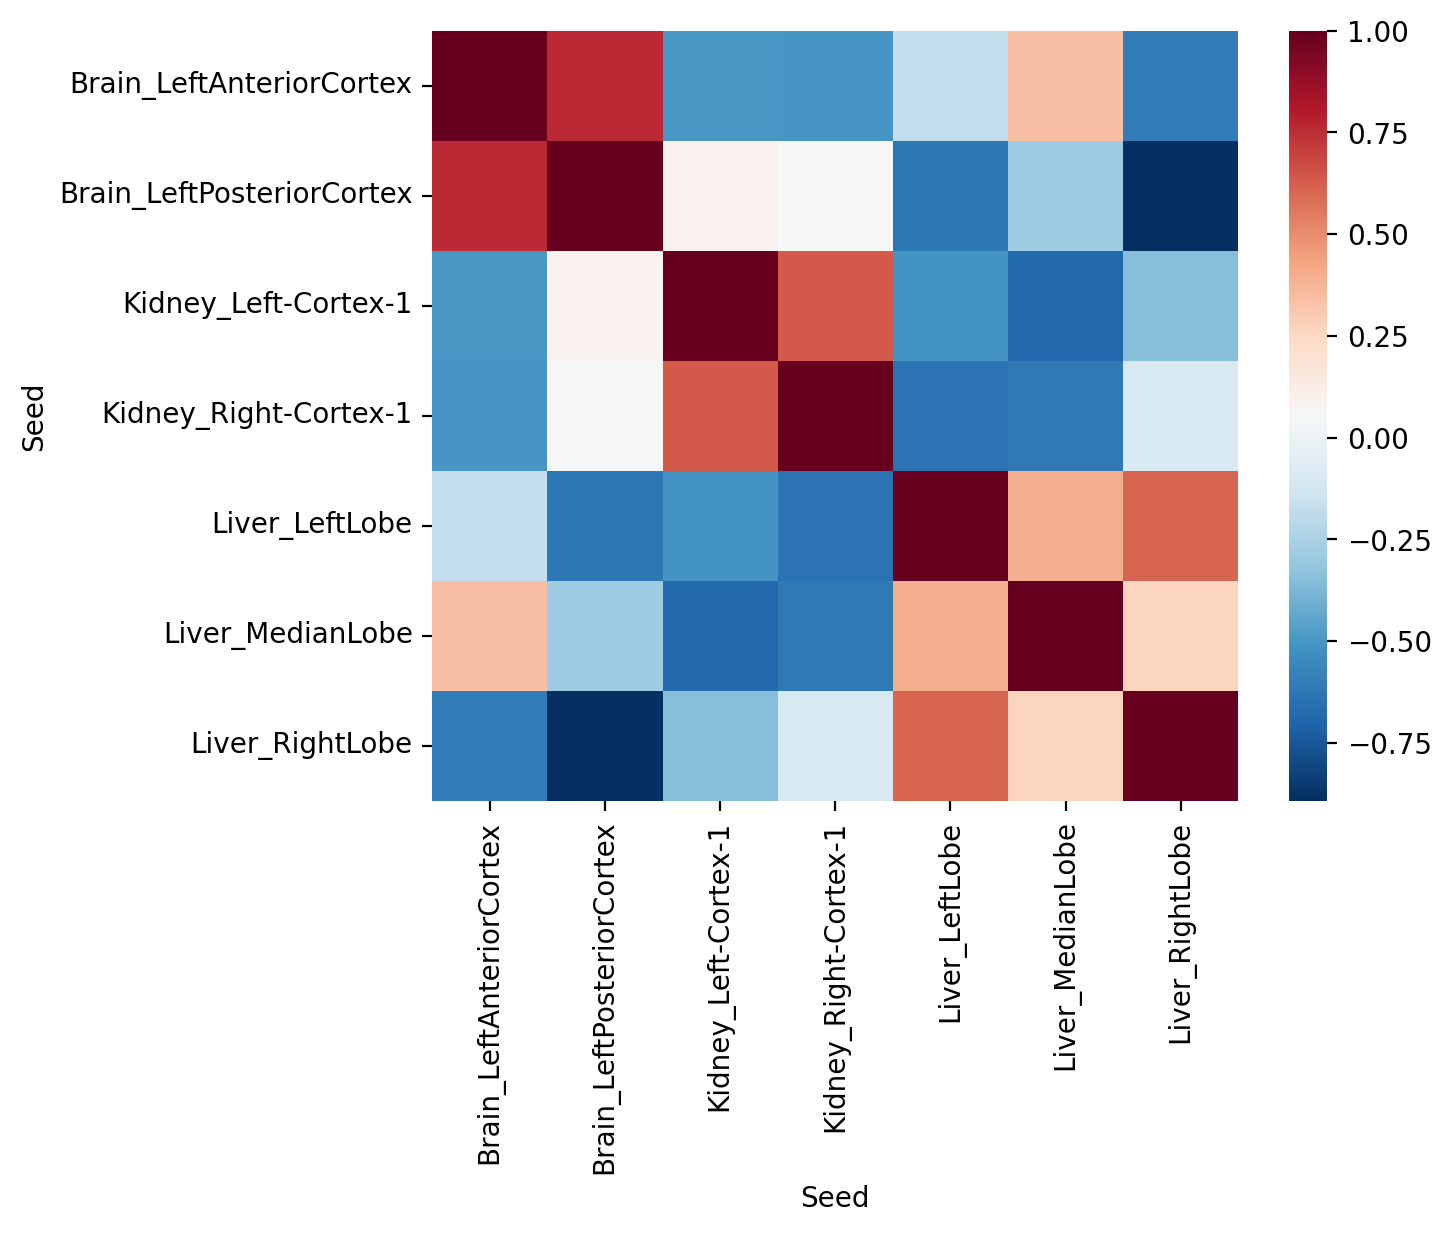

In [31]:
# Heatmap of correlation matrx
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=200)
sns.heatmap(correlation_matrix, cmap='RdBu_r',ax=ax)
plt.show()

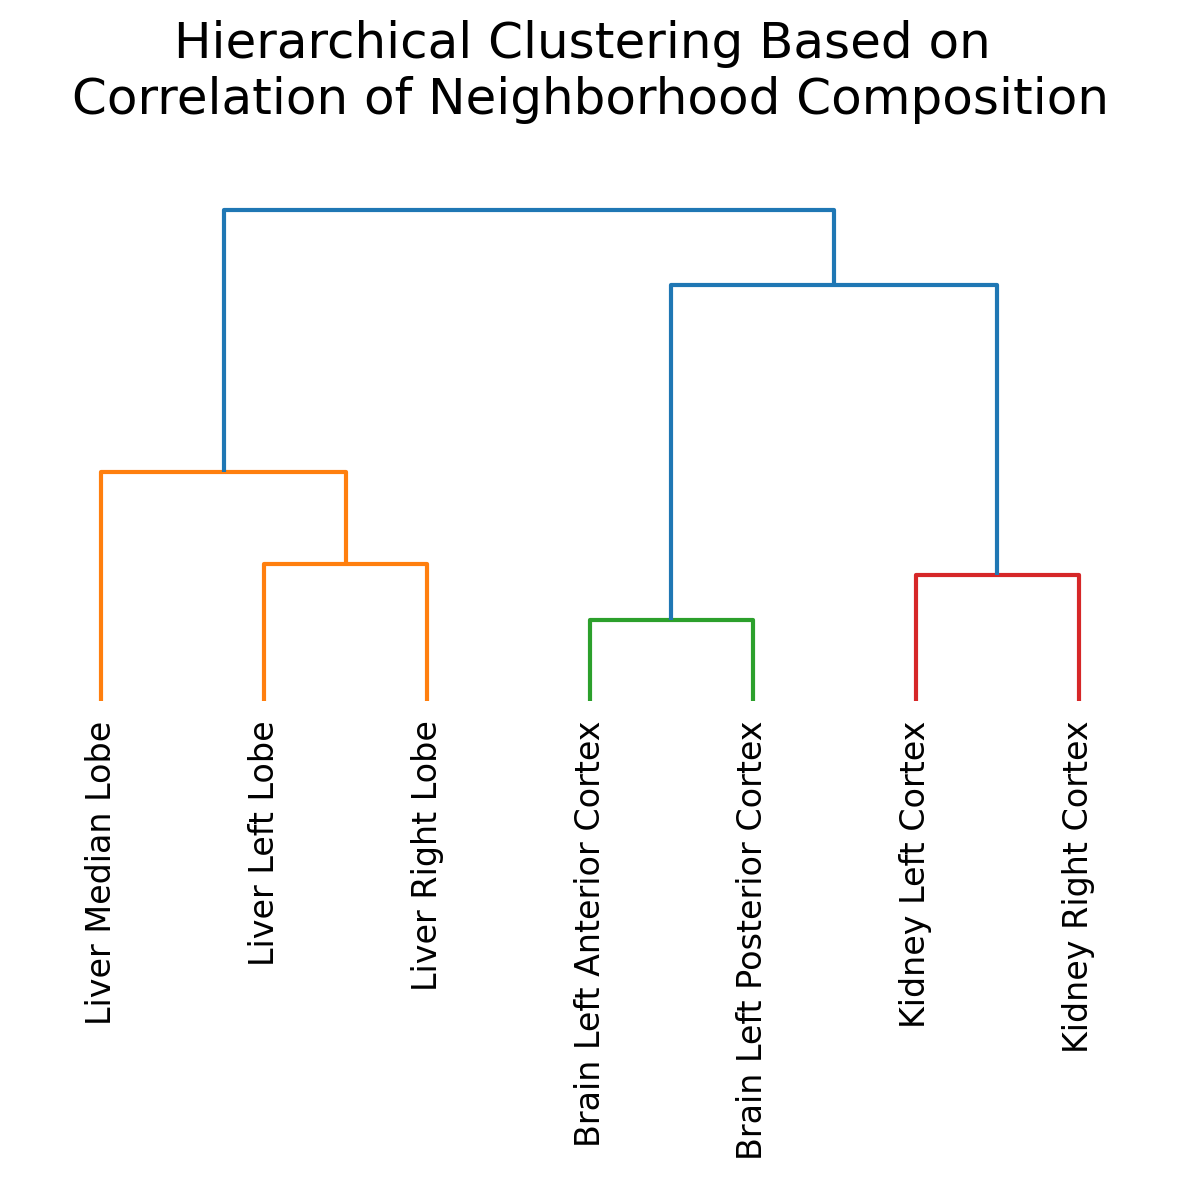

In [34]:
# Plot denrgoram for and rename samples for better visualization
correlation_matrix_renamed_index = [rename_dict[name.lstrip('S.')] for name in correlation_matrix.index]

correlation_distance_matrix = (1 - correlation_matrix).clip(0)  # Correlation distance = 1 - cor
hierarchical_linkage_matrix = linkage(squareform(correlation_distance_matrix), method='average')
dendrogram_result = dendrogram(hierarchical_linkage_matrix, labels=correlation_matrix_renamed_index, no_plot=True)


fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
dendro = dendrogram(hierarchical_linkage_matrix, labels=correlation_matrix_renamed_index, orientation='top',
                    color_threshold=0.8)

plt.title('Hierarchical Clustering Based on \nCorrelation of Neighborhood Composition\n', fontsize=18)
plt.xticks(rotation=90) 

ax.set_yticks([])  # Remove y-tick marks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.savefig('hcluster_neighbor_composition.pdf', bbox_inches='tight')
plt.show()

# Add dendogram for neighbor composition plot

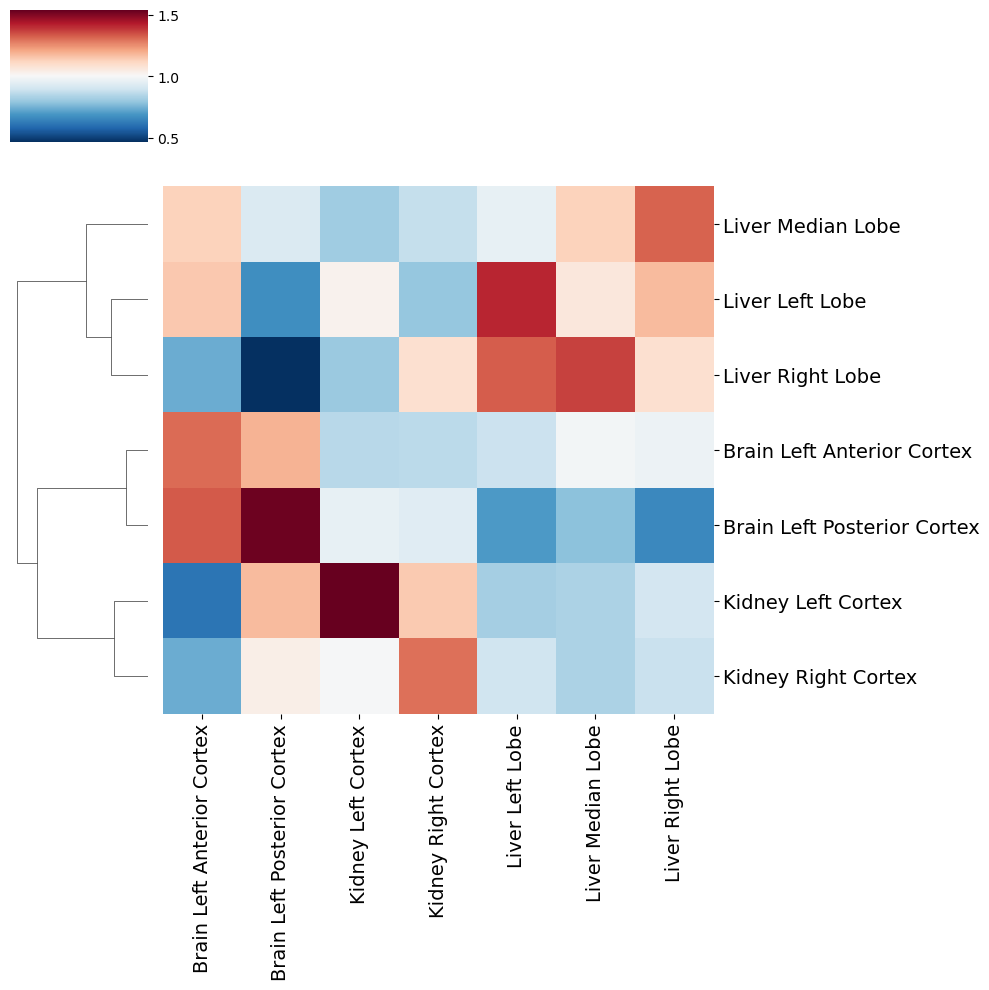

In [33]:
# Use searborn clustermap to add dendogram 
# Default use euclidean distance for making dendrogram, we can specify to use correlation distance
g = sns.clustermap(normalized_neighbor_composition_plot.iloc[:, 1:],
                   cmap='RdBu_r',
                   yticklabels=normalized_neighbor_composition_plot.index,
                   col_cluster=False,
                   metric="correlation",
                   figsize=(10, 10))

# Change tick label sizes
g.ax_heatmap.tick_params(axis='y', labelsize=14)  
g.ax_heatmap.tick_params(axis='x', labelsize=14)

plt.tight_layout()
plt.show()